In [ ]:
from __future__ import division
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imageio
from scipy.optimize import curve_fit
sns.set_style('whitegrid')


def increment_coord(coord, coord_max):
    if coord == coord_max:
        return 0
    else:
        return coord + 1

class Car(object):
    """Representa un automovil rojo y azul en el modelo BML

    Parametros
    ----------
    car_id: id de un carro unico (int)
    color: rojo o azul (string)
    x_coord: coordenadas en x de los puntos de partida (int)
    y_coord: coordenadas en y de los puntos de partida (int)
    """

    def __init__(self, car_id, color, x_coord, y_coord):
        self.car_id = car_id
        self.color = color
        self.x = x_coord
        self.y = y_coord
        self.move_count = 0

    def __repr__(self):
        return "id: {0}, color: {1}, location: {2}".format(
            self.car_id,
            self.color,
            self.get_location()
        )

    def get_location(self):
        return (self.x, self.y)

    def move_car(self, row_max, col_max):
        """Mueve los carros rojos hacia la derecha y los azules hacia arriba.

        Parametros
        ----------
        row_max: maximo de filas en la red (int)
        col_max: maximo de columnas de la red (int)
        """

        if self.color == 'red':
            self.x = increment_coord(self.x, col_max)
        else:
            self.y = increment_coord(self.y, row_max)

        self.move_count += 1

class Grid(object):
    """Representa las celdas donde los carros se mueven.

    Los carros azules se muven en los tiempos impares
    Los carros rojos se mueven en tiempos pares

    Parametros
    ----------
    r/c: Tamaño de la cuadricula r x c
    n_red / n_blue: numero de carros rojos y azules
    n_cars: numero de carros
    density: densidad de carros en la red en el intervalo (0.23,0.47)
    """

    def __init__(self, r, c, n_red=None, n_blue=None, n_cars=None, density=None):
        self.n_red = n_red
        self.n_blue = n_blue

        n_cars = int(r * c * density)
        half_cars = n_cars // 2
        self.n_red = half_cars
        self.n_blue = half_cars

        self.n_cars = self.n_red + self.n_blue
        self.car_loc = {}
        self.r = r - 1
        self.c = c - 1
        self.coords = self._grid_coord(r, c)
        self.step = 0
        self.color_paused = 'blue'
        self.color_move = 'red'
        self.jammed_dict = {'red': False, 'blue': False}
        self.movement = {'red': 0, 'blue': 0}
        self._initialize_cars()

    def __repr__(self):
        return "red: {0}, blue: {1} \nrow: {2}, col: {3}".format(
            self.n_red,
            self.n_blue,
            self.r + 1,
            self.c + 1
        )

    def _grid_coord(self, row, col):
        return np.array([(r, c) for r in range(row) for c in range(col)])

    def is_jammed(self):
        return sum(self.jammed_dict.values()) == 2

    def _initialize_cars(self):
        keep_coords = np.random.choice(len(self.coords), self.n_cars, replace=False)
        car_coords = self.coords[keep_coords]
        car_id = 1
        col = 'red'
        for coord in car_coords:
            self.car_loc[tuple(coord)] = Car(car_id, col, coord[0], coord[1])
            if car_id == self.n_red:
                col = 'blue'
            car_id += 1

    def _get_new_location(self, x, y, color):
        if self.step % 2 == 0:
            if color == 'red':
                x = increment_coord(x, self.c)
        else:
            if color == 'blue':
                y = increment_coord(y, self.r)
        return (x, y)

    def _update_colors(self):
        if self.step % 2 == 0:
            self.color_move, self.color_paused = 'red', 'blue'
        else:
            self.color_move, self.color_paused = 'blue', 'red'

    def _move_cars(self, cars_to_move):
        self.jammed_dict[self.color_move] = len(cars_to_move) == 0
        self.movement[self.color_move] = len(cars_to_move)
        loc_copy = self.car_loc.copy()
        new_locations = set()
        for loc in cars_to_move:
            c = loc_copy[loc]
            c.move_car(self.r, self.c)
            new_loc = c.get_location()
            self.car_loc[new_loc] = c
            new_locations.add(new_loc)
        for loc in cars_to_move.difference(new_locations):
            del self.car_loc[loc]

    def take_step(self):
        self.step += 1
        self._update_colors()
        visited = set()
        to_move = []
        possible_moves = []
        for (x, y), v in self.car_loc.items():
            if ((x, y) in visited) or (v.color == self.color_paused):
                continue
            visited.add((x, y))
            possible_moves.append((x, y))
            new_loc = self._get_new_location(x, y, v.color)
            if new_loc not in self.car_loc:
                to_move.extend(possible_moves)
                possible_moves = []
            else:
                while new_loc in self.car_loc:
                    visited.add(new_loc)
                    car_color = self.car_loc[new_loc].color
                    dup = len(set(possible_moves)) < len(possible_moves)
                    if (car_color == self.color_paused) or dup:
                        possible_moves = []
                        break
                    possible_moves.append(new_loc)
                    new_loc = self._get_new_location(new_loc[0], new_loc[1], car_color)
                else:
                    to_move.extend(possible_moves)
                    possible_moves = []
        self._move_cars(set(to_move))

    def _fix_file_num(self, n, digits):
        n = str(n)
        mult = digits - len(n)
        return '0' * mult + n

    def plot(self, directory='./images', file_num=None, digits=5):
        if not os.path.exists(directory):
            os.makedirs(directory)


        coord_col = [(x, y, v.color) for (x, y), v in self.car_loc.items()]
        coord_col = pd.DataFrame(coord_col, columns=['x', 'y', 'color'])

        if not file_num:
            file_num = self._fix_file_num(self.step, digits)

        filename = '{0}/simulation_step_{1}.png'.format(directory, file_num)

        fig = plt.figure(figsize=(12, 8))
        coord_col.plot(kind='scatter', x='x', y='y', c=coord_col['color'], s=0.4)
        plt.gca().set_axis_off()
        plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
        plt.margins(0.01, 0.01)
        plt.gca().xaxis.set_major_locator(plt.NullLocator())
        plt.gca().yaxis.set_major_locator(plt.NullLocator())
        plt.title('Simulation Step: {0}'.format(self.step))
        plt.savefig(filename)
        plt.close()

        return filename

    def summary(self):
        density = round((self.n_red + self.n_blue) / np.prod((self.r + 1, self.c + 1)), 2)
        total_cars = self.n_red + self.n_blue
        total_move = int(sum([c.move_count for c in self.car_loc.values()]))
        possible_moves = int(self.n_red * self.step / 2 + self.n_blue * self.step / 2)
        velocidad_promedio = round(total_move / possible_moves, 1)
        print('''
        Summary
        -------
        Grid size: {r} x {c}, (rows x cols)
        # red cars: {n_red}, # blue cars: {n_blue}, density: {density}
        Total steps taken: {n_steps}
        Velocidad promedio {velocidad_promedio} percent of the time ({total_move} of {possible_moves})
        Car movement last round: {movement} (of {total_cars})
        The system is jammed: {is_jammed}
        '''.format(
            r=self.r + 1,
            c=self.c + 1,
            n_red=self.n_red,
            n_blue=self.n_blue,
            density=density,
            n_steps=self.step,
            velocidad_promedio=velocidad_promedio,
            total_move=total_move,
            possible_moves=possible_moves,
            movement=sum(self.movement.values()),
            total_cars=total_cars,
            is_jammed=self.is_jammed()
        ))

    def run_simulation(self, n=100, directory='./sim_images', plot_freq=8, gif_loop=-1, gif_speed=100.0 ):
        get_num = lambda n, x: max(int(n * x), 1)
        plot_num = plot_freq if plot_freq > 1 else get_num(n, plot_freq)

        images = []
        for i in range(n):
            if i % plot_num == 0:
                filename = self.plot(directory=directory)
                images.append(imageio.imread(filename))

            self.take_step()

            if self.is_jammed():
                print("Traffic jam!")
                print(i)
                filename = self.plot(directory=directory)
                images.append(imageio.imread(filename))
                break

        self.summary()

        # Guardar imágenes como un archivo GIF
        gif_filename = os.path.join(directory, 'simulation.gif')
        imageio.mimsave(gif_filename, images, duration=gif_speed, loop=gif_loop)


if __name__ == "__main__":
    g = Grid(200, 200, density=0.27)
    g.run_simulation(2000, './sim_images', plot_freq=8, gif_loop=0, gif_speed=150.0)
    final_configuration = g.car_loc

/tmp/ipython-input-7-484657449.py:250: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(filename))
/tmp/ipython-input-7-484657449.py:250: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(filename))
/tmp/ipython-input-7-484657449.py:250: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(filename))
/tmp/ipyth

Traffic jam!
1850


/tmp/ipython-input-7-484657449.py:258: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(filename))



        Summary
        -------
        Grid size: 200 x 200, (rows x cols)
        # red cars: 5400, # blue cars: 5400, density: 0.27
        Total steps taken: 1851
        Velocidad promedio 0.5 percent of the time (4659911 of 9995400)
        Car movement last round: 0 (of 10800)
        The system is jammed: True
        


<Figure size 1200x800 with 0 Axes>

...

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

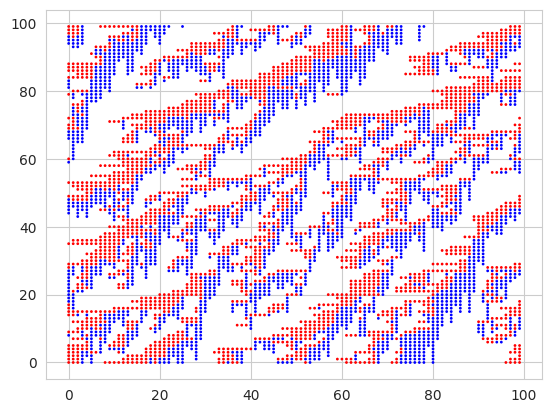

In [ ]:
# Desempaquetar cada objeto Car en sus atributos individuales
df = pd.DataFrame([(car.car_id, car.color, car.x, car.y) for car in final_configuration.values()],
                columns=['car_id', 'color', 'x', 'y'])

# Crear un gráfico de dispersión con matplotlib
plt.scatter(df['x'], df['y'], c=df['color'], s=1)

# Mostrar el gráfico
plt.show()

a = 15.51540019227991


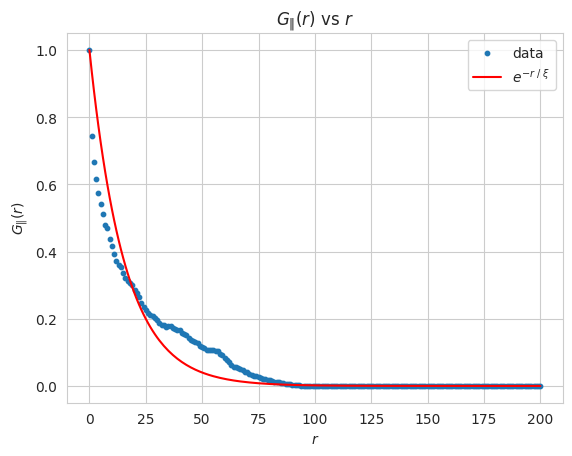

In [ ]:
#----------------------------------------------------------------------------PARALELA----------------------------------------------------------------------------
from scipy.optimize import curve_fit

def calculate_correlation_diagonal(final_configuration, r):
 """Calcula la función de correlación espacial C(r) para la configuración final del sistema en la dirección diagonal.

 Parámetros
 ----------
 final_configuration: diccionario con la configuración final del sistema
 r: distancia para calcular la correlación (int)
 """

 # Calcular la función de correlación espacial C(r) para cada par de posiciones (x, y) y (x + r, y + r)
 correlations = []
 for (x, y), car in final_configuration.items():
    if (x + r, y + r) in final_configuration:
        correlations.append(1)
    else:
        correlations.append(0)

 # Promediar los valores de correlación
 correlation = np.mean(correlations)

 return correlation

def exponential_func(r, a):
   r = np.array(r) # convertir r a un array de numpy
   return np.exp(-r/a)

# Calcular la función de correlación para la configuración final del sistema para diferentes valores de r
r_values = range(0, 201) # Cambia esto al rango de r que desees
correlations = np.zeros(len(r_values))

for i, r in enumerate(r_values):
   correlations[i] = calculate_correlation_diagonal(final_configuration, r)

# ajustar los parámetros de la función
params, params_covariance = curve_fit(exponential_func, r_values, correlations)

# imprimir los parámetros ajustados
print(f"a = {params[0]}")

# hacer predicciones con la función ajustada
predictions = exponential_func(r_values, *params)

# visualizar los datos ajustados
plt.scatter(r_values, correlations, s=10, label='data')
plt.plot(r_values, predictions, 'r-', label='$e^{-r \ / \ ξ}$')
plt.title('$G_{\|}(r)$ vs $r$')
plt.ylabel('$G_{\|}(r)$')
plt.xlabel('$r$')
plt.legend()
plt.show()

a = 10.656288742897331


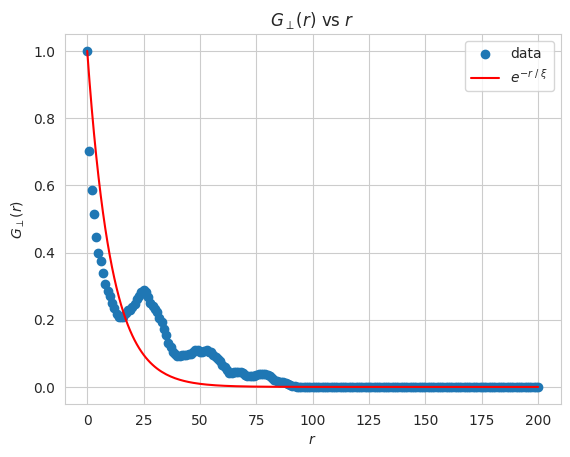

In [ ]:
#----------------------------------------------------------------------------PERPENDICULAR ----------------------------------------------------------------------------
from scipy.optimize import curve_fit

def calculate_correlation_diagonal(final_configuration, r):
 """Calcula la función de correlación espacial C(r) para la configuración final del sistema en la dirección diagonal.

 Parámetros
 ----------
 final_configuration: diccionario con la configuración final del sistema
 r: distancia para calcular la correlación (int)
 """

 # Calcular la función de correlación espacial C(r) para cada par de posiciones (x, y) y (x + r, y + r)
 correlations = []
 for (x, y), car in final_configuration.items():
    if (x - r, y + r) in final_configuration:
        correlations.append(1)
    else:
        correlations.append(0)

 # Promediar los valores de correlación
 correlation = np.mean(correlations)

 return correlation

def exponential_func(r, a):
   r = np.array(r) # convertir r a un array de numpy
   return np.exp(-r/a)

# Calcular la función de correlación para la configuración final del sistema para diferentes valores de r
r_values = range(0, 201) # Cambia esto al rango de r que desees
correlations = np.zeros(len(r_values))

for i, r in enumerate(r_values):
   correlations[i] = calculate_correlation_diagonal(final_configuration, r)

# ajustar los parámetros de la función
params, params_covariance = curve_fit(exponential_func, r_values, correlations)

# imprimir los parámetros ajustados
print(f"a = {params[0]}")

# hacer predicciones con la función ajustada
predictions = exponential_func(r_values, *params)

# visualizar los datos ajustados
plt.scatter(r_values, correlations,label='data')
plt.plot(r_values, predictions, 'r-', label= '$e^{-r \ / \ ξ}$')
plt.title('$G_{\perp}(r)$ vs $r$')
plt.ylabel('$G_{\perp}(r)$')
plt.xlabel('$r$')
plt.legend()
plt.show()

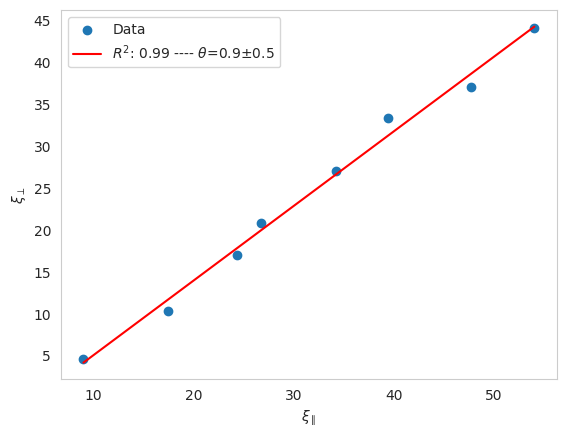

In [ ]:
#-------------------------------------------------------------------------------------------FACTORES DE CORRELACION---------------------------------------------------

parallel = np.array((9.015, 17.418, 24.306, 26.729, 34.243, 39.457, 47.691, 54.060 ))
perpendicular = np.array((4.572, 10.281, 17.037, 20.883, 27.054, 33.416, 37.029, 44.087))

m, b = np.polyfit(parallel, perpendicular, 1)

x_line = np.linspace(min(parallel), max(parallel), 100)
y_line = m*x_line + b

# cálculo del error de la pendiente
n = len(parallel)
residuals = perpendicular - (m * parallel + b)
ss_residuals = np.sum(residuals**2)
ss_total = np.sum((perpendicular - np.mean(perpendicular))**2)
r_squared = 1 - (ss_residuals / ss_total)

# cálculo del error estándar de la pendiente
slope_error = np.sqrt(ss_residuals / (n - 2)) / np.sqrt(n - 1)

#cáclculo del R^{2}
r = np.corrcoef(parallel, perpendicular)[0,1]
r_squared = r**2

plt.scatter(parallel, perpendicular, label="Data")
plt.plot(x_line, y_line, color='red', label=f"$R^2$: {format(r_squared, '.2f')} ---- $\\theta$={format(m, '1.1f')}$\pm${format(slope_error, '1.1f')}")

plt.xlabel(r"$\xi_\parallel}$")
plt.ylabel(r"$\xi_\perp}$")
plt.legend()
plt.grid(False)
plt.show()



In [ ]:
from __future__ import division
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imageio
from scipy.optimize import curve_fit
sns.set_style('whitegrid')


def increment_coord(coord, coord_max):
    """
    Incrementa una coordenada, envolviéndola a 0 si alcanza coord_max.
    """
    if coord == coord_max:
        return 0
    else:
        return coord + 1

class Car(object):
    """Representa un automovil rojo y azul en el modelo BML

    Parametros
    ----------
    car_id: id de un carro unico (int)
    color: rojo o azul (string)
    x_coord: coordenadas en x de los puntos de partida (int)
    y_coord: coordenadas en y de los puntos de partida (int)
    """

    def __init__(self, car_id, color, x_coord, y_coord):
        self.car_id = car_id
        self.color = color
        self.x = x_coord
        self.y = y_coord
        self.move_count = 0

    def __repr__(self):
        return "id: {0}, color: {1}, location: {2}".format(
            self.car_id,
            self.color,
            self.get_location()
        )

    def get_location(self):
        """Devuelve las coordenadas actuales del coche."""
        return (self.x, self.y)

    def move_car(self, row_max, col_max):
        """Mueve los carros rojos hacia la derecha y los azules hacia arriba.

        Parametros
        ----------
        row_max: maximo de filas en la red (int)
        col_max: maximo de columnas de la red (int)
        """

        if self.color == 'red':
            self.x = increment_coord(self.x, col_max)
        else: # self.color == 'blue'
            self.y = increment_coord(self.y, row_max)

        self.move_count += 1

class Grid(object):
    """Representa las celdas donde los carros se mueven.

    Los carros azules se muven en los tiempos impares
    Los carros rojos se mueven en tiempos pares

    Parametros
    ----------
    r/c: Tamaño de la cuadricula r x c
    n_red / n_blue: numero de carros rojos y azules
    n_cars: numero de carros
    density: densidad de carros en la red en el intervalo (0.23,0.47)
    """

    def __init__(self, r, c, n_red=None, n_blue=None, n_cars=None, density=None):
        self.r_dim = r # Guardamos las dimensiones originales para el plot y summary
        self.c_dim = c

        if density is not None:
            n_cars = int(r * c * density)
            half_cars = n_cars // 2
            self.n_red = half_cars
            self.n_blue = n_cars - half_cars # Asegura que el total sea n_cars
        elif n_red is not None and n_blue is not None:
            self.n_red = n_red
            self.n_blue = n_blue
        else:
            raise ValueError("Debe proporcionar 'density' o 'n_red' y 'n_blue'.")

        self.n_cars = self.n_red + self.n_blue
        self.car_loc = {} # Diccionario { (x, y): Car_object }

        # Maximos indices para increment_coord (r-1, c-1)
        self.r = r - 1
        self.c = c - 1

        self.coords = self._grid_coord(r, c) # Todas las coordenadas posibles en la cuadrícula
        self.step = 0
        self.color_paused = 'blue' # Por defecto, en el paso 0 se moverán los rojos (paso par)
        self.color_move = 'red'
        self.jammed_dict = {'red': False, 'blue': False}
        self.movement = {'red': 0, 'blue': 0}
        self._initialize_cars()

    def __repr__(self):
        return "red: {0}, blue: {1} \nrow: {2}, col: {3}".format(
            self.n_red,
            self.n_blue,
            self.r_dim,
            self.c_dim
        )

    def _grid_coord(self, row, col):
        """Genera todas las coordenadas (fila, columna) de la cuadrícula."""
        return np.array([(r, c) for r in range(row) for c in range(col)])

    def is_jammed(self):
        """Retorna True si ambos tipos de carros están atascados."""
        return sum(self.jammed_dict.values()) == 2

    def _initialize_cars(self):
        """Inicializa los carros en posiciones aleatorias de la cuadrícula."""
        # Selecciona n_cars coordenadas únicas al azar
        keep_coords_indices = np.random.choice(len(self.coords), self.n_cars, replace=False)
        car_coords = self.coords[keep_coords_indices]

        car_id = 1

        # Asigna primero los coches rojos, luego los azules
        for i, coord in enumerate(car_coords):
            color = 'red' if i < self.n_red else 'blue'
            self.car_loc[tuple(coord)] = Car(car_id, color, coord[0], coord[1])
            car_id += 1

    def _get_new_location(self, x, y, color):
        """Calcula la ubicación potencial de un coche si se mueve."""
        if color == 'red':
            return (increment_coord(x, self.c), y)
        else: # color == 'blue'
            return (x, increment_coord(y, self.r))

    def _update_colors(self):
        """Alterna el color de los carros que pueden moverse en cada paso."""
        if self.step % 2 == 0: # Pasos pares: rojos se mueven
            self.color_move, self.color_paused = 'red', 'blue'
        else: # Pasos impares: azules se mueven
            self.color_move, self.color_paused = 'blue', 'red'

    def _move_cars(self, cars_to_move_original_locations):
        """
        Ejecuta el movimiento de los carros que han sido identificados como capaces de moverse.
        Actualiza el diccionario car_loc de manera segura.
        """

        # Actualiza el estado de atasco y el conteo de movimientos para el color actual
        self.jammed_dict[self.color_move] = len(cars_to_move_original_locations) == 0
        self.movement[self.color_move] = len(cars_to_move_original_locations)

        temp_car_loc = {}
        moved_cars_objects = [] # Lista para almacenar los objetos Car que se movieron

        # Primero, identifica los coches que se moverán y actualiza sus atributos internos
        for old_loc in cars_to_move_original_locations:
            car_obj = self.car_loc[old_loc]
            car_obj.move_car(self.r, self.c) # Actualiza las coordenadas x, y dentro del objeto Car
            moved_cars_objects.append(car_obj)

        # Reconstruye el diccionario self.car_loc
        # 1. Añade los coches que NO se movieron a las nuevas ubicaciones (que son las mismas que las viejas)
        for loc, car_obj in self.car_loc.items():
            if loc not in cars_to_move_original_locations:
                temp_car_loc[loc] = car_obj

        # 2. Añade los coches que SÍ se movieron a sus nuevas ubicaciones
        for car_obj in moved_cars_objects:
            temp_car_loc[car_obj.get_location()] = car_obj

        self.car_loc = temp_car_loc # Reemplaza el diccionario original

    def take_step(self):
        """
        Realiza un paso de la simulación. Los carros del color activo intentan moverse.
        Un carro se mueve si su celda de destino está vacía.
        """
        self.step += 1
        self._update_colors()

        # Lista para almacenar las ubicaciones originales de los coches que *pueden* moverse
        # en este paso.
        cars_actually_moving_original_locations = set()

        # Es crucial iterar sobre una copia de las claves para evitar problemas
        # si se modifica el diccionario durante la iteración
        current_car_locations = list(self.car_loc.keys())

        # Primera fase: Identificar qué coches pueden moverse
        for old_loc in current_car_locations:
            if old_loc not in self.car_loc: # Si el coche ya se movió en este paso (no debería pasar con esta lógica)
                continue

            car_obj = self.car_loc[old_loc]

            if car_obj.color == self.color_move: # Solo consideramos coches del color activo
                new_loc = self._get_new_location(old_loc[0], old_loc[1], car_obj.color)

                # Un coche se mueve si su celda de destino está VACÍA
                if new_loc not in self.car_loc:
                    cars_actually_moving_original_locations.add(old_loc)

        # Segunda fase: Ejecutar los movimientos de los coches identificados
        self._move_cars(cars_actually_moving_original_locations)


    def _fix_file_num(self, n, digits):
        """Formatea un número con ceros a la izquierda para un nombre de archivo consistente."""
        n = str(n)
        mult = digits - len(n)
        return '0' * mult + n

    def plot(self, directory='./images', file_num=None, digits=5):
        """
        Genera y guarda una imagen del estado actual de la simulación.
        """
        if not os.path.exists(directory):
            os.makedirs(directory)

        # Prepara los datos para el plot
        coord_col = [(x, y, v.color) for (x, y), v in self.car_loc.items()]
        coord_col = pd.DataFrame(coord_col, columns=['x', 'y', 'color'])

        if not file_num:
            file_num = self._fix_file_num(self.step, digits)

        filename = '{0}/simulation_step_{1}.png'.format(directory, file_num)

        fig = plt.figure(figsize=(12, 8))

        # Mapear colores a valores numéricos para seaborn scatter con 'c'
        color_map = {'red': 0, 'blue': 1}
        colors = coord_col['color'].map(color_map)

        # Plot usando scatter de matplotlib directamente para más control
        plt.scatter(coord_col['x'], coord_col['y'], c=colors, cmap='bwr', s=10, marker='o') # 'bwr' es un buen colormap para rojo/azul

        # Establecer límites para la cuadrícula
        plt.xlim(0, self.c_dim)
        plt.ylim(0, self.r_dim)

        # Invertir el eje Y para que (0,0) esté en la parte inferior izquierda si es necesario
        # plt.gca().invert_yaxis() # Descomentar si prefieres Y creciente hacia arriba

        plt.gca().set_axis_off() # Elimina los ejes
        plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
        plt.margins(0.01, 0.01)
        plt.gca().xaxis.set_major_locator(plt.NullLocator())
        plt.gca().yaxis.set_major_locator(plt.NullLocator())
        plt.title('Simulation Step: {0}'.format(self.step))
        plt.savefig(filename)
        plt.close(fig) # Cierra la figura para liberar memoria

        return filename

    def summary(self):
        """Imprime un resumen del estado actual de la simulación."""
        density = round((self.n_red + self.n_blue) / (self.r_dim * self.c_dim), 4) # Usar dimensiones originales para densidad
        total_cars = self.n_red + self.n_blue
        total_move = int(sum([c.move_count for c in self.car_loc.values()]))

        # Si el paso es 0, possible_moves sería 0, evitar división por cero
        if self.step > 0:
            # En el BML, cada coche tiene 0.5 de oportunidad de intentar moverse por paso de simulación
            # porque solo se mueve en el turno de su color.
            possible_moves_per_car_per_step = 0.5
            possible_total_moves = total_cars * self.step * possible_moves_per_car_per_step
            # Si un color no se ha movido nunca porque su turno nunca llegó o se atascó muy rápido, esto puede ser 0
            # Si self.step es impar, uno de los colores no ha tenido tantas oportunidades como el otro.
            # Para la velocidad promedio, se suele considerar el total de movimientos realizados dividido por el total de movimientos posibles.
            # Aquí, la velocidad promedio se calcula como la proporción de movimientos realizados sobre el total de movimientos posibles si todo fluyera
            if possible_total_moves > 0:
                velocidad_promedio = round(total_move / possible_total_moves, 4)
            else:
                velocidad_promedio = 0.0
        else:
            velocidad_promedio = 0.0


        print('''
        Summary
        -------
        Grid size: {r} x {c}, (rows x cols)
        # red cars: {n_red}, # blue cars: {n_blue}, density: {density}
        Total steps taken: {n_steps}
        Velocidad promedio: {velocidad_promedio} (total moves: {total_move}, possible moves: {possible_total_moves})
        Car movement last round: {movement} (of {total_cars})
        The system is jammed: {is_jammed}
        '''.format(
            r=self.r_dim, # Usa las dimensiones originales para la presentación
            c=self.c_dim,
            n_red=self.n_red,
            n_blue=self.n_blue,
            density=density,
            n_steps=self.step,
            velocidad_promedio=velocidad_promedio,
            total_move=total_move,
            possible_total_moves=int(possible_total_moves) if self.step > 0 else 0,
            movement=sum(self.movement.values()),
            total_cars=total_cars,
            is_jammed=self.is_jammed()
        ))

    def run_simulation(self, n=100, directory='./sim_images', plot_freq=8, gif_loop=-1, gif_speed=100.0):
        """
        Ejecuta la simulación por 'n' pasos, generando plots y un GIF.

        Parametros
        ----------
        n: Número total de pasos de simulación.
        directory: Directorio donde se guardarán las imágenes y el GIF.
        plot_freq: Frecuencia con la que se generan las imágenes (ej: 8 = cada 8 pasos).
        gif_loop: Cuántas veces se repite el GIF (-1 para siempre, 0 para una vez).
        gif_speed: Retraso entre frames en milisegundos (ms).
        """
        get_num = lambda n_steps, freq: max(int(n_steps * freq), 1) # Esto parece ser para plot_freq como fracción
        # Simplificamos: si plot_freq es 1, 2, 8, etc., se toma como un intervalo.
        # Si plot_freq es menor que 1 (ej: 0.1), se toma como una fracción de n.
        if plot_freq < 1:
            plot_interval = max(1, int(n * plot_freq))
        else:
            plot_interval = int(plot_freq)

        images = []
        print(f"Starting simulation for {n} steps. Plotting every {plot_interval} steps.")

        for i in range(n):
            if i % plot_interval == 0:
                print(f"Plotting step {i}...")
                filename = self.plot(directory=directory)
                images.append(imageio.imread(filename))

            self.take_step()

            if self.is_jammed():
                print(f"Traffic jam detected at step {i}!")
                filename = self.plot(directory=directory, file_num=f"JAMMED_{self.step}") # Guardar el último estado
                images.append(imageio.imread(filename))
                break # Detener la simulación si hay atasco

        self.summary()

        # Guardar imágenes como un archivo GIF
        if images: # Solo intentar guardar GIF si hay imágenes
            gif_filename = os.path.join(directory, 'simulation.gif')
            print(f"Saving GIF to {gif_filename} with {len(images)} frames...")
            imageio.mimsave(gif_filename, images, duration=gif_speed / 1000.0, loop=gif_loop) # duration en segundos
        else:
            print("No images were generated for the GIF.")

if __name__ == "__main__":
    g = Grid(100, 100, density=0.6)
    g.run_simulation(4000, './sim_images', plot_freq=8, gif_loop=0, gif_speed=150.0)
    final_configuration = g.car_loc

Starting simulation for 4000 steps. Plotting every 8 steps.
Plotting step 0...


/tmp/ipython-input-14-4072850892.py:343: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(filename))


Plotting step 8...


/tmp/ipython-input-14-4072850892.py:343: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(filename))


Plotting step 16...


...

Plotting step 520...


/tmp/ipython-input-14-4072850892.py:343: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(filename))


Traffic jam detected at step 524!


/tmp/ipython-input-14-4072850892.py:350: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(filename))



        Summary
        -------
        Grid size: 100 x 100, (rows x cols)
        # red cars: 3000, # blue cars: 3000, density: 0.6
        Total steps taken: 525
        Velocidad promedio: 0.0923 (total moves: 145390, possible moves: 1575000)
        Car movement last round: 0 (of 6000)
        The system is jammed: True
        
Saving GIF to ./sim_images/simulation.gif with 67 frames...
